In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [4]:
data=load_breast_cancer()
x=pd.DataFrame(data=data.data, columns=data.feature_names)
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
x.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

In [6]:
y=pd.Series((data.target==0).astype(int),name="malignant")

In [7]:
print(y.value_counts())

malignant
0    357
1    212
Name: count, dtype: int64


In [9]:
print("shape of data",x.shape)
print("shape of target",y.shape)
print(data.target_names)


shape of data (569, 30)
shape of target (569,)
['malignant' 'benign']


In [ ]:
class_counts = y.value_counts().sort_index()
class_probabilities = y.value_counts(normalize=True).sort_index()

class_distribution = pd.DataFrame({
    "Class": data.target_names,
    "Count": class_counts.values,
    "Probability": class_probabilities.values
})

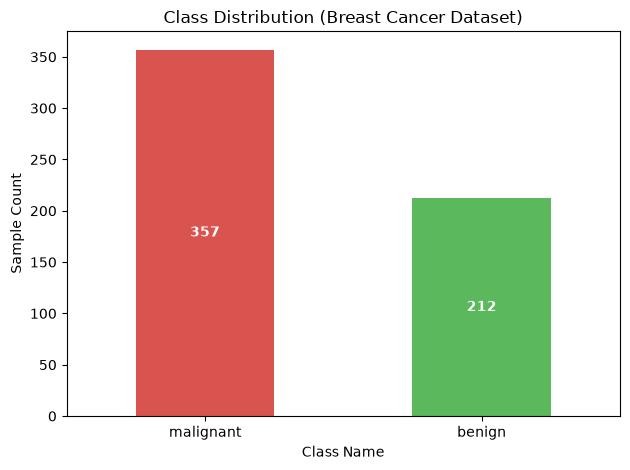

In [24]:
import matplotlib.pyplot as plt

# Plot bar chart directly from the DataFrame
ax = class_distribution.plot(
    x="Class", 
    y="Count", 
    kind="bar", 
    legend=False, 
    color=["#d9534f", "#5cb85c"]  # Red for malignant, Green for benign
)

plt.title("Class Distribution (Breast Cancer Dataset)")
plt.xlabel("Class Name")
plt.ylabel("Sample Count")
plt.xticks(rotation=0)

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
X_train,X_test,Y_train,Y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print("training size",len(Y_train))

print("\n Training prop")
print(Y_train.value_counts(normalize=True).sort_index())

print("\n Test prop")
print(Y_test.value_counts(normalize=True).sort_index())

training size 455

 Training prop
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

 Test prop
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [19]:
model=make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [22]:
probab=model.predict_proba(X_test)
print(probab[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [23]:
print(probab[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [27]:
results = pd.DataFrame({
    "Actual_class":Y_test.values,
    "P_malignant":probab[:,0],
    "P_benign":probab[:,1]
})
print(results.head(10))

   Actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [31]:
threshold=0.50
results["Predicted_malignant"]=(
    results["P_malignant"]>=threshold
).astype(int)

results["predicted_label"]=results[
    "Predicted_malignant"
].map({
    1:"Malignant",
    0:"Benign"
})
print(
    results[[
        "Actual_class",
        "P_malignant",
        "predicted_label"
     ] ]
)

     Actual_class   P_malignant predicted_label
0               0  9.996354e-01       Malignant
1               1  1.074660e-08          Benign
2               0  9.574321e-01       Malignant
3               1  4.238127e-01          Benign
4               0  4.908445e-01          Benign
..            ...           ...             ...
109             0  9.998799e-01       Malignant
110             0  9.996350e-01       Malignant
111             0  8.844442e-01       Malignant
112             1  5.083901e-01       Malignant
113             1  7.446726e-04          Benign

[114 rows x 3 columns]


In [32]:
for threshold in [0.3,0.5,0.7]:
    predictions=(
        results["P_malignant"] >=threshold
    ).astype(int)
    print(
        f"threshold = {threshold}"
        f"malignant= {predictions.sum()}"

    )

threshold = 0.3malignant= 76
threshold = 0.5malignant= 74
threshold = 0.7malignant= 72


In [49]:

actual_malignant = (Y_test.values == 0).astype(int)
metric_results=[]
for threshold in [0.1,0.3, 0.5, 0.7,0.9]:
  
    predicted_malignant = (results["P_malignant"] >= threshold).astype(int)
    
    print("\n")
    cm = confusion_matrix(actual_malignant, predicted_malignant, labels=[1, 0])
    print("threshold==",threshold)
    print(cm)
    
    tp = cm[0, 0]
    fn = cm[0, 1]
    fp = cm[1, 0]
    tn = cm[1, 1]

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * sensitivity) / (precision +sensitivity) if (precision + sensitivity) > 0 else 0
    specificity=tn/(tn+fp) if (tn+fp) >0 else 0

    metric_results.append({
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Accuracy": accuracy,
        "Precision": precision,
        "sensitivity": sensitivity,
        "F1_Score": f1_score,
        "Specificity": specificity
    })

metrics_df = pd.DataFrame(metric_results)


display(metrics_df.round(4))



threshold== 0.1
[[72  0]
 [ 9 33]]


threshold== 0.3
[[72  0]
 [ 4 38]]


threshold== 0.5
[[71  1]
 [ 3 39]]


threshold== 0.7
[[71  1]
 [ 1 41]]


threshold== 0.9
[[67  5]
 [ 1 41]]


,Threshold,TP,FP,FN,TN,Accuracy,Precision,sensitivity,F1_Score,Specificity
0,0.1,72,9,0,33,0.9211,0.8889,1.0000,0.9412,0.7857
1,0.3,72,4,0,38,0.9649,0.9474,1.0000,0.9730,0.9048
2,0.5,71,3,1,39,0.9649,0.9595,0.9861,0.9726,0.9286
3,0.7,71,1,1,41,0.9825,0.9861,0.9861,0.9861,0.9762
4,0.9,67,1,5,41,0.9474,0.9853,0.9306,0.9571,0.9762


In [ ]:
plt.plot